Using Device: cuda

Scanning dataset...

Skipping Corrupted Image: /kaggle/input/datasets/arjunsudheer326/tomato-plant-stages-dataset/Tomato_Plant_Stages_Dataset/Stage2_Flowering_Initiation/1710490230456.jpg
Skipping Corrupted Image: /kaggle/input/datasets/arjunsudheer326/tomato-plant-stages-dataset/Tomato_Plant_Stages_Dataset/Stage2_Flowering_Initiation/1710490230430.jpg
Skipping Corrupted Image: /kaggle/input/datasets/arjunsudheer326/tomato-plant-stages-dataset/Tomato_Plant_Stages_Dataset/Stage2_Flowering_Initiation/1710490230470.jpg
Skipping Corrupted Image: /kaggle/input/datasets/arjunsudheer326/tomato-plant-stages-dataset/Tomato_Plant_Stages_Dataset/Stage2_Flowering_Initiation/1710490230476.jpg

Classes: ['Stage1_Early_Vegetative', 'Stage2_Flowering_Initiation']
Number of Classes: 2
Total Valid Images: 442


/tmp/ipykernel_57/1572294711.py:211: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
  0%|          | 0/10 [00:00<?, ?it/s]/tmp/ipykernel_57/1572294711.py:249: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/15: 100%|██████████| 10/10 [00:28<00:00,  2.82s/it]



Epoch [1/15]
Train Loss: 0.5588
Train Accuracy: 80.26%
Validation Loss: 0.2935
Validation Accuracy: 95.45%
Best Model Saved!


Epoch 2/15: 100%|██████████| 10/10 [00:26<00:00,  2.66s/it]



Epoch [2/15]
Train Loss: 0.1871
Train Accuracy: 100.00%
Validation Loss: 0.0820
Validation Accuracy: 95.45%


...


Epoch [7/15]
Train Loss: 0.0059
Train Accuracy: 100.00%
Validation Loss: 0.0083
Validation Accuracy: 100.00%


Epoch 8/15: 100%|██████████| 10/10 [00:26<00:00,  2.69s/it]



Epoch [8/15]
Train Loss: 0.0043
Train Accuracy: 100.00%
Validation Loss: 0.0080
Validation Accuracy: 100.00%


Epoch 9/15: 100%|██████████| 10/10 [00:28<00:00,  2.87s/it]



Epoch [9/15]
Train Loss: 0.0029
Train Accuracy: 100.00%
Validation Loss: 0.0040
Validation Accuracy: 100.00%

Early Stopping Triggered!


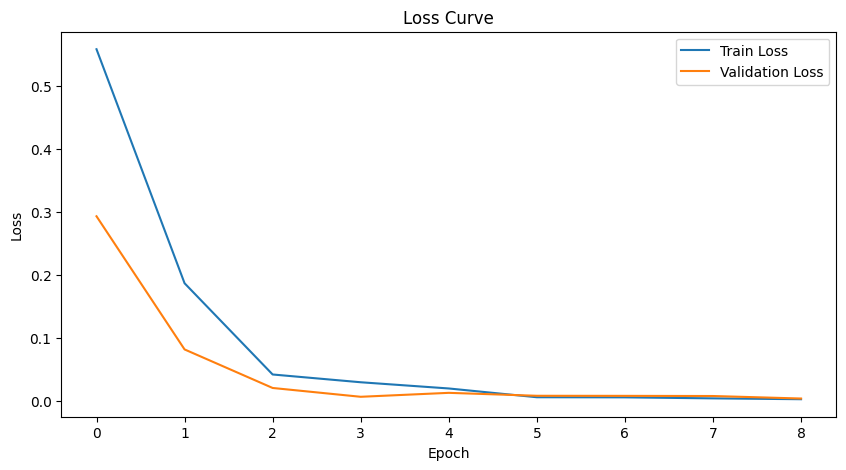

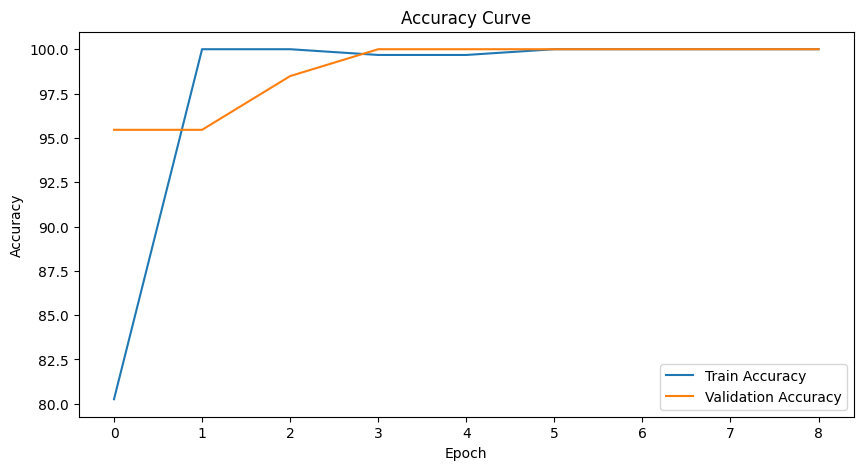

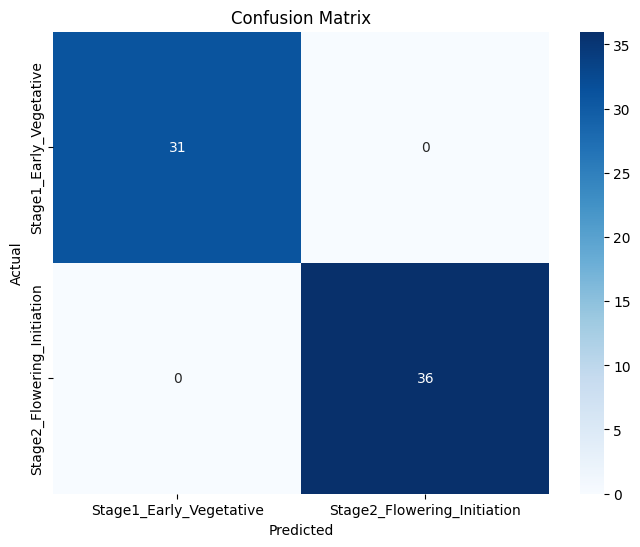


Classification Report:

                             precision    recall  f1-score   support

    Stage1_Early_Vegetative       1.00      1.00      1.00        31
Stage2_Flowering_Initiation       1.00      1.00      1.00        36

                   accuracy                           1.00        67
                  macro avg       1.00      1.00      1.00        67
               weighted avg       1.00      1.00      1.00        67


TRAINING COMPLETE

Saved Files:
✔ /kaggle/working/best_resnet50_model.pth
✔ /kaggle/working/final_resnet50_model.pth
✔ /kaggle/working/loss_curve.png
✔ /kaggle/working/accuracy_curve.png
✔ /kaggle/working/confusion_matrix.png
✔ /kaggle/working/classification_report.txt


In [2]:
# ==========================================
# RESNET50 TRAINING FOR TOMATO PLANT STAGE DETECTION
# ==========================================

!pip install -q torch torchvision seaborn scikit-learn tqdm

# ==========================================
# IMPORTS
# ==========================================
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader, random_split

from tqdm import tqdm

# ==========================================
# DEVICE
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

# ==========================================
# DATASET PATH
# ==========================================
DATASET_PATH = "dataset-path"

# ==========================================
# TRANSFORMS
# ==========================================
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

# ==========================================
# CUSTOM DATASET
# ==========================================
class SafeImageDataset(Dataset):

    def __init__(self, root_dir, transform=None):

        self.root_dir = root_dir
        self.transform = transform

        self.image_paths = []
        self.labels = []

        self.classes = sorted([
            folder for folder in os.listdir(root_dir)
            if os.path.isdir(os.path.join(root_dir, folder))
        ])

        print("\nScanning dataset...\n")

        for label, class_name in enumerate(self.classes):

            class_dir = os.path.join(root_dir, class_name)

            for file_name in os.listdir(class_dir):

                file_path = os.path.join(class_dir, file_name)

                try:
                    img = Image.open(file_path)
                    img.verify()

                    self.image_paths.append(file_path)
                    self.labels.append(label)

                except Exception:
                    print(f"Skipping Corrupted Image: {file_path}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):

        image_path = self.image_paths[idx]
        label = self.labels[idx]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

# ==========================================
# LOAD DATASET
# ==========================================
full_dataset = SafeImageDataset(
    DATASET_PATH,
    transform=train_transform
)

class_names = full_dataset.classes
num_classes = len(class_names)

print("\nClasses:", class_names)
print("Number of Classes:", num_classes)
print("Total Valid Images:", len(full_dataset))

# ==========================================
# TRAIN / VAL / TEST SPLIT
# ==========================================
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size]
)

# Apply different transforms
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = test_transform
test_dataset.dataset.transform = test_transform

# ==========================================
# DATALOADERS
# ==========================================
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# ==========================================
# LOAD PRETRAINED RESNET50
# ==========================================
model = models.resnet50(
    weights=models.ResNet50_Weights.DEFAULT
)

# Replace final layer
model.fc = nn.Linear(
    model.fc.in_features,
    num_classes
)

model = model.to(device)

# ==========================================
# LOSS & OPTIMIZER
# ==========================================
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

# ==========================================
# MIXED PRECISION
# ==========================================
scaler = torch.cuda.amp.GradScaler()

# ==========================================
# TRAINING
# ==========================================
EPOCHS = 15

train_losses = []
val_losses = []

train_accs = []
val_accs = []

best_val_acc = 0

early_stop_counter = 0
PATIENCE = 5

for epoch in range(EPOCHS):

    # ======================================
    # TRAIN
    # ======================================
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    train_bar = tqdm(train_loader)

    for images, labels in train_bar:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():

            outputs = model(images)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (preds == labels).sum().item()

        train_bar.set_description(
            f"Epoch {epoch+1}/{EPOCHS}"
        )

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # ======================================
    # VALIDATION
    # ======================================
    model.eval()

    val_running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (preds == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_acc = 100 * correct / total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.2f}%")

    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {val_acc:.2f}%")

    # ======================================
    # SAVE BEST MODEL
    # ======================================
    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            "/kaggle/working/best_resnet50_model.pth"
        )

        print("Best Model Saved!")

        early_stop_counter = 0

    else:
        early_stop_counter += 1

    # ======================================
    # EARLY STOPPING
    # ======================================
    if early_stop_counter >= PATIENCE:

        print("\nEarly Stopping Triggered!")
        break

# ==========================================
# PLOT LOSS CURVES
# ==========================================
plt.figure(figsize=(10,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")

plt.legend()

plt.savefig("/kaggle/working/loss_curve.png")

plt.show()

# ==========================================
# PLOT ACCURACY CURVES
# ==========================================
plt.figure(figsize=(10,5))

plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Accuracy Curve")

plt.legend()

plt.savefig("/kaggle/working/accuracy_curve.png")

plt.show()

# ==========================================
# LOAD BEST MODEL
# ==========================================
model.load_state_dict(
    torch.load("/kaggle/working/best_resnet50_model.pth")
)

# ==========================================
# TESTING
# ==========================================
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# ==========================================
# CONFUSION MATRIX
# ==========================================
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.savefig("/kaggle/working/confusion_matrix.png")

plt.show()

# ==========================================
# CLASSIFICATION REPORT
# ==========================================
report = classification_report(
    all_labels,
    all_preds,
    target_names=class_names
)

print("\nClassification Report:\n")
print(report)

with open(
    "/kaggle/working/classification_report.txt",
    "w"
) as f:

    f.write(report)

# ==========================================
# SAVE FINAL MODEL
# ==========================================
torch.save(
    model,
    "/kaggle/working/final_resnet50_model.pth"
)

print("\n===================================")
print("TRAINING COMPLETE")
print("===================================")

print("\nSaved Files:")

print("✔ /kaggle/working/best_resnet50_model.pth")
print("✔ /kaggle/working/final_resnet50_model.pth")
print("✔ /kaggle/working/loss_curve.png")
print("✔ /kaggle/working/accuracy_curve.png")
print("✔ /kaggle/working/confusion_matrix.png")
print("✔ /kaggle/working/classification_report.txt")